<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly-Detection-MetroPT3/blob/main/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⬇️ Downloading dataset...
--2026-03-23 07:14:29--  https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1209663443 (1.1G) [text/plain]
Saving to: ‘MetroPT2.csv’

MetroPT2.csv        100%[===================>]   1.13G  15.9MB/s    in 74s     

2026-03-23 07:15:44 (15.6 MB/s) - ‘MetroPT2.csv’ saved [1209663443/1209663443]

✅ Download completed
📊 Number of features: 20


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 20)         │         1,300 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,084 (219.08 KB)

 Trainable params: 56,084 (219.08 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training using chunks...
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences
✅ Trained on chunk: 49990 sequences



🎯 Training completed without RAM crash!
💾 Model saved!

📊 Quick check...


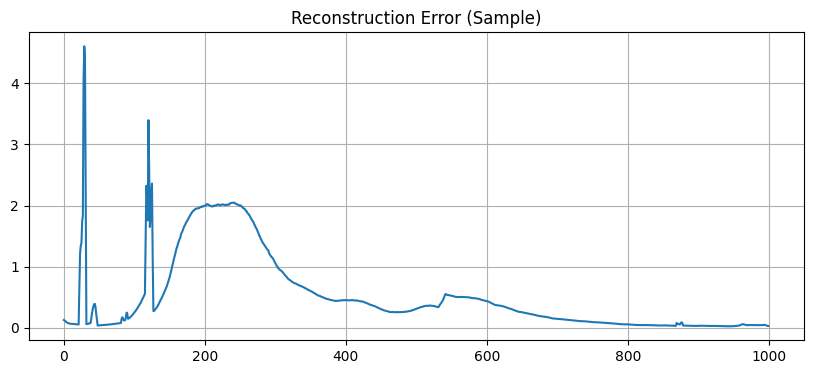


✅ Pipeline completed successfully!


In [4]:
# =========================================================
# 🚆 PREDICTIVE MAINTENANCE - LSTM AUTOENCODER (PRO VERSION)
# =========================================================

# 🔧 Fix TensorFlow warning
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# =========================================================
# 0. DOWNLOAD DATA
# =========================================================

print("⬇️ Downloading dataset...")

!wget https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1 -O MetroPT2.csv

print("✅ Download completed")

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout

# =========================================================
# 2. SETTINGS
# =========================================================

DATA_PATH = "MetroPT2.csv"
CHUNK_SIZE = 50000
TIMESTEPS = 10
BATCH_SIZE = 32

scaler = StandardScaler()

# =========================================================
# 3. GET NUMBER OF FEATURES (🔥 IMPORTANT)
# =========================================================

first_chunk = next(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE))

if first_chunk.columns[0].lower() in ["unnamed: 0", "index"]:
    first_chunk = first_chunk.drop(first_chunk.columns[0], axis=1)

feature_cols = first_chunk.select_dtypes(include=[np.number]).columns.tolist()

if "is_anomaly" in feature_cols:
    feature_cols.remove("is_anomaly")

n_features = len(feature_cols)

print("📊 Number of features:", n_features)

# =========================================================
# 4. CREATE SEQUENCES FUNCTION
# =========================================================

def create_sequences(data, timesteps=10):
    Xs = []
    for i in range(len(data) - timesteps):
        Xs.append(data[i:i+timesteps])
    return np.array(Xs)

# =========================================================
# 5. BUILD MODEL
# =========================================================

inputs = Input(shape=(TIMESTEPS, n_features))

x = LSTM(64, activation="tanh", return_sequences=False)(inputs)
x = Dropout(0.3)(x)

x = RepeatVector(TIMESTEPS)(x)

x = LSTM(64, activation="tanh", return_sequences=True)(x)
outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()

# =========================================================
# 6. TRAINING WITH CHUNKS
# =========================================================

print("\n🚀 Training using chunks...")

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):

    # تنظيف
    if chunk.columns[0].lower() in ["unnamed: 0", "index"]:
        chunk = chunk.drop(chunk.columns[0], axis=1)

    # timestamp
    chunk["timestamp"] = pd.to_datetime(chunk["timestamp"])
    chunk = chunk.sort_values("timestamp")

    # labels
    chunk["is_anomaly"] = 0
    failure_windows = [
        ("2022-06-01", "2022-06-02"),
        ("2022-07-10", "2022-07-11")
    ]

    for start, end in failure_windows:
        mask = (chunk["timestamp"] >= start) & (chunk["timestamp"] <= end)
        chunk.loc[mask, "is_anomaly"] = 1

    # features
    feature_cols = chunk.select_dtypes(include=[np.number]).columns.tolist()
    if "is_anomaly" in feature_cols:
        feature_cols.remove("is_anomaly")

    X_chunk = chunk[feature_cols].values.astype(np.float32)

    # scaling
    X_chunk = scaler.fit_transform(X_chunk)

    # فقط normal data للتدريب
    train_mask = (chunk["timestamp"] < "2022-06-01") & (chunk["is_anomaly"] == 0)
    X_train_chunk = X_chunk[train_mask]

    if len(X_train_chunk) < TIMESTEPS:
        continue

    # windowing
    X_seq = create_sequences(X_train_chunk, TIMESTEPS)

    if len(X_seq) == 0:
        continue

    # تدريب تدريجي
    model.fit(
        X_seq, X_seq,
        epochs=1,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    print(f"✅ Trained on chunk: {len(X_seq)} sequences")

print("\n🎯 Training completed without RAM crash!")

# =========================================================
# 7. SAVE MODEL
# =========================================================

model.save("lstm_autoencoder_model.h5")
print("💾 Model saved!")

# =========================================================
# 8. SIMPLE VISUALIZATION (OPTIONAL)
# =========================================================

print("\n📊 Quick check...")

sample_chunk = next(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE))

if sample_chunk.columns[0].lower() in ["unnamed: 0", "index"]:
    sample_chunk = sample_chunk.drop(sample_chunk.columns[0], axis=1)

sample_chunk["timestamp"] = pd.to_datetime(sample_chunk["timestamp"])

feature_cols = sample_chunk.select_dtypes(include=[np.number]).columns.tolist()
if "is_anomaly" in feature_cols:
    feature_cols.remove("is_anomaly")

X_sample = scaler.transform(sample_chunk[feature_cols].values.astype(np.float32))

X_seq_sample = create_sequences(X_sample, TIMESTEPS)

pred = model.predict(X_seq_sample[:1000], verbose=0)
error = np.mean((X_seq_sample[:1000] - pred)**2, axis=(1,2))

plt.figure(figsize=(10,4))
plt.plot(error)
plt.title("Reconstruction Error (Sample)")
plt.grid()
plt.show()

print("\n✅ Pipeline completed successfully!")